### **1. Load Canary Wharf bounday**

In [1]:
from pathlib import Path
import html
import json
from typing import Any, cast

import duckdb
import folium
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display
from folium.plugins import MarkerCluster
from shapely import from_wkb
from shapely.geometry import Point
from shapely.geometry.base import BaseGeometry

In [2]:
pd.set_option('display.max_columns', 200)
sns.set_theme(style='whitegrid')

project_root = Path.cwd()
if project_root.name == 'code':
    project_root = project_root.parent

code_dir = project_root / 'code'
data_dir = project_root / 'data'
output_dir = project_root / 'output'
code_dir.mkdir(parents=True, exist_ok=True)
output_dir.mkdir(parents=True, exist_ok=True)

aoi_path = Path('/content/drive/MyDrive/CUSP-GX 7103 7113 CAPSTONE/CAPSTONE WORK PROGRESS/Data/Boundaries/canary_wharf.geojson')
if not aoi_path.exists():
    raise FileNotFoundError(f'AOI file not found: {aoi_path}')

aoi_name = 'Canary Wharf'
top_n_display_categories = 8
nearest_building_distance_m = 15
max_poi_markers = 1200
export_map_html = True

aoi_source = gpd.read_file(aoi_path)
if aoi_source.empty:
    raise ValueError(f'AOI file contains no features: {aoi_path}')

if aoi_source.crs is None:
    aoi_source = aoi_source.set_crs('EPSG:4326')
else:
    aoi_source = aoi_source.to_crs('EPSG:4326')

aoi_geometry = cast(BaseGeometry, aoi_source.geometry.union_all())
aoi = gpd.GeoDataFrame(
    {'aoi_name': [aoi_name]},
    geometry=gpd.GeoSeries([aoi_geometry], crs='EPSG:4326'),
    crs='EPSG:4326',
)
west, south, east, north = aoi.total_bounds
aoi_bbox = {
    'west': float(west),
    'south': float(south),
    'east': float(east),
    'north': float(north),
}

display(aoi)

,aoi_name,geometry
0,Canary Wharf,"POLYGON ((-0.02478 51.50052, -0.02495 51.50052..."


In [3]:
def init_overture_connection() -> tuple[duckdb.DuckDBPyConnection, str]:
    con = duckdb.connect()
    for statement in [
        'INSTALL spatial',
        'INSTALL httpfs',
        'LOAD spatial',
        'LOAD httpfs',
        "SET s3_region='us-west-2'",
    ]:
        con.execute(statement)

    latest_release = con.execute(
        "SELECT latest FROM 'https://stac.overturemaps.org/catalog.json'"
    ).fetchone()
    if latest_release is None:
        raise RuntimeError('Could not read the latest Overture release from STAC.')
    release_name = str(latest_release[0])
    return con, release_name


def parquet_path(release: str, theme: str, type_name: str) -> str:
    return (
        f's3://overturemaps-us-west-2/release/{release}'
        f'/theme={theme}/type={type_name}/*'
    )


def parse_wkb(value: object) -> BaseGeometry:
    if value is None:
        raise TypeError('Geometry WKB value cannot be None.')
    if isinstance(value, memoryview):
        value = value.tobytes()
    if isinstance(value, bytearray):
        value = bytes(value)
    if isinstance(value, bytes):
        return cast(BaseGeometry, from_wkb(value))
    raise TypeError(f'Unsupported WKB value type: {type(value)!r}')


def wkb_df_to_gdf(
    df: pd.DataFrame,
    geometry_col: str = 'geometry_wkb',
    crs: str = 'EPSG:4326',
) -> gpd.GeoDataFrame:
    geometry_values: list[BaseGeometry] = [parse_wkb(value) for value in df[geometry_col].tolist()]
    geometry = gpd.GeoSeries(geometry_values, crs=crs)
    gdf = gpd.GeoDataFrame(df.drop(columns=[geometry_col]).copy(), geometry=geometry, crs=crs)
    return gdf


def is_missing_scalar(value: object) -> bool:
    if value is None or value is pd.NA:
        return True
    if isinstance(value, float):
        return bool(np.isnan(value))
    if isinstance(value, np.floating):
        return bool(np.isnan(float(value)))
    return False


def parse_taxonomy_json(value: object) -> dict[str, Any] | None:
    if is_missing_scalar(value):
        return None
    if isinstance(value, str):
        if value.strip() == '':
            return None
        parsed = json.loads(value)
        return cast(dict[str, Any], parsed) if isinstance(parsed, dict) else None
    if isinstance(value, dict):
        return cast(dict[str, Any], value)
    return None


def slug_to_label(value: object) -> str:
    if is_missing_scalar(value):
        return 'Unknown'
    text_value = str(value)
    if text_value == '':
        return 'Unknown'
    return text_value.replace('_', ' ').title()


def as_text(value: object, default: str = 'Unknown') -> str:
    if is_missing_scalar(value):
        return default
    text_value = str(value)
    return default if text_value == '' else text_value


def as_int(value: object, default: int = 0) -> int:
    if is_missing_scalar(value):
        return default
    if isinstance(value, bool):
        return int(value)
    if isinstance(value, (int, np.integer)):
        return int(value)
    if isinstance(value, (float, np.floating)):
        return default if np.isnan(float(value)) else int(value)
    if isinstance(value, str):
        stripped_value = value.strip()
        if stripped_value == '':
            return default
        try:
            return int(float(stripped_value))
        except ValueError:
            return default
    return default


def as_str_list(value: object) -> list[str]:
    if isinstance(value, list):
        return [str(item) for item in value]
    return []


def series_text(row: pd.Series, key: str, default: str = 'Unknown') -> str:
    return as_text(row.get(key), default=default)


def series_geometry(row: pd.Series, key: str = 'geometry') -> BaseGeometry | None:
    geometry_value = row.get(key)
    if geometry_value is None:
        return None
    return cast(BaseGeometry, geometry_value)


def series_hierarchy(row: pd.Series, key: str = 'taxonomy_hierarchy') -> list[str]:
    value = row.get(key)
    if isinstance(value, list):
        return [str(item) for item in value if item]
    return []


def taxonomy_primary(value: dict[str, Any] | None) -> str | None:
    if value is None:
        return None
    primary = value.get('primary')
    return str(primary) if primary is not None else None


def taxonomy_hierarchy(value: dict[str, Any] | None) -> list[str]:
    if value is None:
        return []
    hierarchy = value.get('hierarchy', [])
    if isinstance(hierarchy, list):
        return [str(item) for item in hierarchy if item]
    return []


def build_building_tooltip(row: pd.Series) -> str:
    building_id = series_text(row, 'id', default='n/a')
    poi_sum = as_int(row.get('poi_sum'))
    dominant_category = series_text(row, 'dominant_category', default='No matched POIs')
    return f'building_id: {building_id} | poi_sum: {poi_sum} | dominant: {dominant_category}'


def build_poi_tooltip(row: pd.Series) -> str:
    primary_name = series_text(row, 'primary_name')
    basic_category = series_text(row, 'basic_category')
    compact_category = series_text(row, 'analysis_category_limited')
    match_method = series_text(row, 'building_match_method')
    return (
        f"<b>Name:</b> {html.escape(primary_name)}<br>"
        f"<b>Basic category:</b> {html.escape(basic_category)}<br>"
        f"<b>Compact category:</b> {html.escape(compact_category)}<br>"
        f"<b>Match method:</b> {html.escape(match_method)}"
    )


def point_from_row(row: pd.Series) -> Point | None:
    geometry_value = series_geometry(row)
    if geometry_value is None or geometry_value.is_empty or geometry_value.geom_type != 'Point':
        return None
    return cast(Point, geometry_value)

### **2. Fetch Overture Places and Buildings for the AOI**

In [4]:
con, latest_release = init_overture_connection()

west = aoi_bbox['west']
south = aoi_bbox['south']
east = aoi_bbox['east']
north = aoi_bbox['north']

places_query = f"""
SELECT
    id,
    names.primary AS primary_name,
    basic_category,
    CAST(taxonomy AS JSON) AS taxonomy_json,
    confidence,
    operating_status,
    ST_AsWKB(geometry) AS geometry_wkb
FROM read_parquet(
    '{parquet_path(latest_release, 'places', 'place')}',
    filename=true,
    hive_partitioning=1
)
WHERE
    bbox.xmin BETWEEN {west} AND {east}
    AND bbox.ymin BETWEEN {south} AND {north}
    AND coalesce(operating_status, 'open') <> 'permanently_closed'
    AND coalesce(confidence, 1.0) > 0
"""

buildings_query = f"""
SELECT
    id,
    names.primary AS building_name,
    class AS building_class,
    subtype AS building_subtype,
    height,
    num_floors,
    ST_AsWKB(geometry) AS geometry_wkb
FROM read_parquet(
    '{parquet_path(latest_release, 'buildings', 'building')}',
    filename=true,
    hive_partitioning=1
)
WHERE
    bbox.xmin <= {east}
    AND bbox.xmax >= {west}
    AND bbox.ymin <= {north}
    AND bbox.ymax >= {south}
"""

places_raw = con.execute(places_query).df()
buildings_raw = con.execute(buildings_query).df()

print(f'Latest Overture release: {latest_release}')
print(f'Places fetched from remote API/storage: {len(places_raw):,}')
print(f'Buildings fetched from remote API/storage: {len(buildings_raw):,}')


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Latest Overture release: 2026-03-18.0
Places fetched from remote API/storage: 3,134
Buildings fetched from remote API/storage: 1,120


In [5]:
place_aoi_filtered = wkb_df_to_gdf(places_raw)
building_aoi_filtered = wkb_df_to_gdf(buildings_raw)

place_aoi_filtered['taxonomy_json'] = place_aoi_filtered['taxonomy_json'].map(parse_taxonomy_json)
place_aoi_filtered['taxonomy_hierarchy'] = place_aoi_filtered['taxonomy_json'].map(taxonomy_hierarchy)
place_aoi_filtered['taxonomy_primary'] = place_aoi_filtered['taxonomy_json'].map(taxonomy_primary)
place_aoi_filtered['taxonomy_l0'] = place_aoi_filtered['taxonomy_hierarchy'].map(
    lambda values: values[0] if isinstance(values, list) and len(values) > 0 else None
)

place_aoi_filtered = place_aoi_filtered[place_aoi_filtered.intersects(aoi_geometry)].copy()
building_aoi_filtered = building_aoi_filtered[
    building_aoi_filtered.intersects(aoi_geometry) &
    building_aoi_filtered['building_subtype'].notnull() &
    building_aoi_filtered['building_class'].notnull()
].copy()

place_aoi = place_aoi_filtered.copy()
building_aoi = building_aoi_filtered.copy()

display(
    pd.DataFrame(
        {
            'layer': ['place_aoi', 'building_aoi'],
            'rows': [len(place_aoi), len(building_aoi)],
            'crs': [str(place_aoi.crs), str(building_aoi.crs)],
        }
    )
)

display(
    pd.DataFrame(
        {
            'place_aoi_fields': pd.Series(place_aoi.columns, dtype='string'),
            'building_aoi_fields': pd.Series(building_aoi.columns, dtype='string'),
        }
    )
)

display(place_aoi.head(3))
display(building_aoi.head(3))

,layer,rows,crs
0,place_aoi,2460,EPSG:4326
1,building_aoi,320,EPSG:4326


,place_aoi_fields,building_aoi_fields
0,id,id
1,primary_name,building_name
2,basic_category,building_class
3,taxonomy_json,building_subtype
4,confidence,height
5,operating_status,num_floors
6,geometry,geometry
7,taxonomy_hierarchy,<NA>
8,taxonomy_primary,<NA>
9,taxonomy_l0,<NA>


,id,primary_name,basic_category,taxonomy_json,confidence,operating_status,geometry,taxonomy_hierarchy,taxonomy_primary,taxonomy_l0
1,57d23081-fe25-41fc-8140-d9c8af98b28c,Mendoza Contract Cleaning,home_service,"{'primary': 'home_cleaning', 'hierarchy': ['se...",0.938874,open,POINT (-0.02055 51.50095),"[services_and_business, home_service, home_cle...",home_cleaning,services_and_business
2,b46891ea-3e2a-485c-9fb2-4a0e94cfffa5,Bella Cosa Restaurant,restaurant,"{'primary': 'italian_restaurant', 'hierarchy':...",0.998116,open,POINT (-0.01227 51.50067),"[food_and_drink, restaurant, european_restaura...",italian_restaurant,food_and_drink
3,3309baca-349e-4208-a9c1-e3b4174d8093,Vectone Mobile,corporate_or_business_office,"{'primary': 'corporate_office', 'hierarchy': [...",0.770000,open,POINT (-0.021 51.50083),"[services_and_business, private_establishments...",corporate_office,services_and_business


,id,building_name,building_class,building_subtype,height,num_floors,geometry
7,817735f9-1eb0-4207-abe7-89dfd839e6a0,Scott House,commercial,commercial,NaN,4,"POLYGON ((-0.02067 51.50169, -0.02087 51.50171..."
19,e2f90314-e645-4984-9566-085e02e68866,None,apartments,residential,NaN,<NA>,"POLYGON ((-0.02509 51.50091, -0.02509 51.50089..."
21,df7ce21f-41f6-4c43-8338-0361af031f86,None,apartments,residential,NaN,<NA>,"POLYGON ((-0.02354 51.50099, -0.02392 51.50101..."


In [6]:
print('\nBuilding Subtype Distribution:')
display(building_aoi['building_subtype'].value_counts())

print('Building Class Distribution:')
display(building_aoi['building_class'].value_counts())


Building Subtype Distribution:


,count
building_subtype,
residential,167
commercial,92
service,33
outbuilding,12
transportation,11
industrial,4
education,1


Building Class Distribution:


,count
building_class,
apartments,85
commercial,39
house,39
office,37
service,33
residential,29
warehouse,9
roof,8
train_station,6


In [7]:
import plotly.express as px

# Prepare data for the treemap
treemap_data = building_aoi.groupby(['building_subtype', 'building_class']).size().reset_index(name='count')

# Add a 'total' category for the root of the treemap
treemap_data['all'] = 'All Buildings'


In [8]:
# Create the interactive treemap
fig = px.treemap(
    treemap_data,
    path=['all', 'building_subtype', 'building_class'],
    values='count',
    title='Building Subtype and Class Distribution (Interactive Treemap)',
    color='building_subtype', # Color by building_subtype
    color_discrete_sequence=px.colors.qualitative.Plotly # Use a qualitative color sequence
)

# Update layout for better visibility
fig.update_layout(margin=dict(t=50, l=25, r=25, b=25))

# Display the figure
fig.show()


In [9]:
# Get unique building subtypes for coloring
unique_subtypes = building_aoi['building_subtype'].dropna().unique()

# Generate a color palette for each subtype
colors = sns.color_palette('tab20', n_colors=len(unique_subtypes))
subtype_to_color = {subtype: f'#{int(c[0]*255):02x}{int(c[1]*255):02x}{int(c[2]*255):02x}' for subtype, c in zip(unique_subtypes, colors)}

# Create a Folium map centered on the AOI
m = folium.Map(
    location=[aoi_bbox['south'] + (aoi_bbox['north'] - aoi_bbox['south']) / 2,
              aoi_bbox['west'] + (aoi_bbox['east'] - aoi_bbox['west']) / 2],
    zoom_start=15
)

# Add a GeoJson layer for buildings
# This approach directly uses the GeoDataFrame's geometry
folium.GeoJson(
    building_aoi.to_json(),
    style_function=lambda feature:
    {
        'fillColor': subtype_to_color.get(feature['properties']['building_subtype'], '#808080'), # Default to grey if subtype not found
        'color': 'black',
        'weight': 1,
        'fillOpacity': 0.7
    },
    tooltip=folium.features.GeoJsonTooltip(
        fields=[
            'building_name',
            'building_class',
            'building_subtype',
            'height',
            'num_floors'
        ],
        aliases=[
            'Name:',
            'Class:',
            'Subtype:',
            'Height (m):',
            'Num Floors:'
        ],
        localize=True
    )
).add_to(m)

# Add a layer control to the map
folium.LayerControl().add_to(m)

# Display the map
display(m)

Number of buildings with missing 'building_subtype' (represented in grey on the map): 0


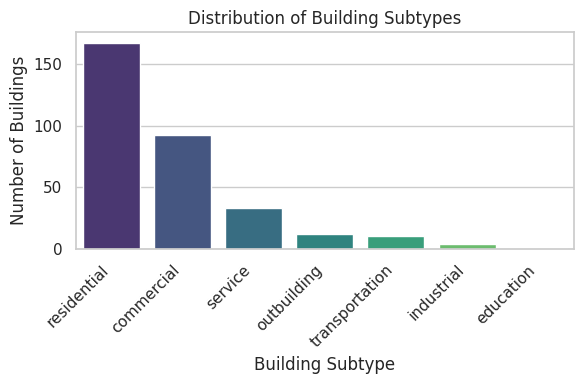

In [10]:
# Count buildings with missing building_subtype
missing_subtype_count = building_aoi['building_subtype'].isnull().sum()
print(f"Number of buildings with missing 'building_subtype' (represented in grey on the map): {missing_subtype_count}")

# Calculate the distribution of building subtypes
subtype_counts = building_aoi['building_subtype'].value_counts().sort_values(ascending=False)

# Create a bar chart for building subtypes
plt.figure(figsize=(6, 4))
sns.barplot(x=subtype_counts.index, y=subtype_counts.values, hue=subtype_counts.index, palette='viridis', legend=False)
plt.title('Distribution of Building Subtypes')
plt.xlabel('Building Subtype')
plt.ylabel('Number of Buildings')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### **2. Assign POIs to Buildings**

In [11]:
analysis_crs = building_aoi.estimate_utm_crs()
if analysis_crs is None:
    raise ValueError('Could not estimate a projected CRS for the AOI.')

place_metric = place_aoi.to_crs(analysis_crs)
building_metric = building_aoi.to_crs(analysis_crs).copy()
building_metric['building_area_m2'] = building_metric.area

place_metric_points = gpd.GeoDataFrame(
    place_metric[['geometry']].copy(),
    geometry='geometry',
    crs=analysis_crs,
)
building_metric_polygons = gpd.GeoDataFrame(
    building_metric[['id', 'building_area_m2', 'geometry']].copy(),
    geometry='geometry',
    crs=analysis_crs,
)

within_join = gpd.sjoin(
    place_metric_points,
    building_metric_polygons,
    how='left',
    predicate='within',
).reset_index(names='place_index')

within_best = (
    within_join.dropna(subset=['id'])
    .sort_values(['place_index', 'building_area_m2'])
    .drop_duplicates(subset='place_index')
    .rename(columns={'id': 'building_id'})[['place_index', 'building_id']]
)
within_best['building_match_method'] = 'within'
within_best['snap_distance_m'] = 0.0

place_assignments = within_best.copy()
matched_place_index_set = set(place_assignments['place_index'].tolist())
unmatched_index_list = [index_value for index_value in place_aoi.index.tolist() if index_value not in matched_place_index_set]

if len(unmatched_index_list) > 0:
    unmatched_points = gpd.GeoDataFrame(
        place_metric.loc[unmatched_index_list, ['geometry']].copy(),
        geometry='geometry',
        crs=analysis_crs,
    )
    building_metric_nearest = gpd.GeoDataFrame(
        building_metric[['id', 'geometry']].copy(),
        geometry='geometry',
        crs=analysis_crs,
    )
    nearest_join = gpd.sjoin_nearest(
        unmatched_points,
        building_metric_nearest,
        how='left',
        max_distance=nearest_building_distance_m,
        distance_col='snap_distance_m',
    ).reset_index(names='place_index')

    nearest_best = (
        nearest_join.dropna(subset=['id'])
        .sort_values(['place_index', 'snap_distance_m'])
        .drop_duplicates(subset='place_index')
        .rename(columns={'id': 'building_id'})[['place_index', 'building_id', 'snap_distance_m']]
    )
    nearest_best['building_match_method'] = 'nearest'
    place_assignments = pd.concat([place_assignments, nearest_best], ignore_index=True)

place_aoi = place_aoi.merge(place_assignments, left_index=True, right_on='place_index', how='left')
place_aoi = place_aoi.set_index('place_index').sort_index()
place_aoi['building_match_method'] = place_aoi['building_match_method'].fillna('unmatched')
place_aoi['is_assigned_to_building'] = place_aoi['building_id'].notna()
place_aoi = gpd.GeoDataFrame(place_aoi, geometry='geometry', crs='EPSG:4326')
place_aoi.columns = pd.Index([str(column) for column in place_aoi.columns], dtype='object')

building_lookup = pd.DataFrame(
    building_aoi.loc[:, ['id', 'building_name', 'building_class', 'building_subtype', 'height', 'num_floors']].copy()
)
building_lookup = building_lookup.rename(columns={'id': 'building_id'})
place_aoi = place_aoi.merge(building_lookup, on='building_id', how='left')
place_aoi = gpd.GeoDataFrame(place_aoi, geometry='geometry', crs='EPSG:4326')
place_aoi.columns = pd.Index([str(column) for column in place_aoi.columns], dtype='object')

coverage_summary = pd.DataFrame(
    {
        'poi_count': place_aoi['building_match_method'].value_counts().reindex(
            ['within', 'nearest', 'unmatched'],
            fill_value=0,
        )
    }
)
coverage_summary['share_pct'] = coverage_summary['poi_count'] / len(place_aoi) * 100
display(coverage_summary)

,poi_count,share_pct
building_match_method,,
within,1333,54.186992
nearest,790,32.113821
unmatched,337,13.699187


### **3. Build a Compact Category Rollup**

In [12]:
# 定义精细化的 POI 集合
hq_specific_categories = {'corporate_office', 'office', 'government_office'}
business_service_categories = {'professional_services', 'financial_service', 'business_to_business'}

def derive_analysis_category(row: pd.Series) -> str:
    basic = str(row.get('basic_category', '')).lower()
    l0 = str(row.get('taxonomy_l0', '')).lower()

    # 1. Office HQ (纯办公点)
    if basic in hq_specific_categories:
        return 'Work_HQ'

    # 2. Business Services (专业服务/办事机构)
    if l0 in business_service_categories:
        return 'Work_Services'

    # 3. Food & Drink
    if l0 == 'food_and_drink':
        return 'Food_Drink'

    # 4. Retail (包含 Leisure)
    if l0 == 'retail' or l0 == 'arts_and_entertainment':
        return 'Retail_Leisure'

    # 5. Education (独立)
    if l0 == 'education':
        return 'Education'

    # 6. Medical (独立)
    if l0 == 'health_and_medical':
        return 'Medical'

    # 7. Transportation
    if l0 in {'transportation', 'travel'}:
        return 'Transportation'

    # 其他统归为 Other (后续 Building 逻辑会处理它)
    return 'Other'

# 应用分类
place_aoi['analysis_category'] = place_aoi.apply(derive_analysis_category, axis=1)

# 注意：这里跳过原代码中那个 "top_n_display_categories" 的限制，
# 因为我们需要所有精确定义的类别来做 Building 判定。
place_aoi['analysis_category_limited'] = place_aoi['analysis_category']

In [19]:
import numpy as np
import pandas as pd
import json
import folium
import seaborn as sns

# ==========================================
# 1. 增强型 POI 类别定义
# ==========================================
def derive_analysis_category_v4(row):
    basic = str(row.get('basic_category', '')).lower()
    l0 = str(row.get('taxonomy_l0', '')).lower()
    primary = str(row.get('taxonomy_primary', '')).lower()

    work_keys = {'office', 'corporate', 'headquarter', 'bank', 'finance', 'financial',
                 'consulting', 'legal', 'law', 'investment', 'equity', 'insurance', 'professional', 'management'}

    is_work = any(k in basic for k in work_keys) or any(k in l0 for k in work_keys) or any(k in primary for k in work_keys)

    if is_work: return 'Work'
    if 'food' in l0 or 'drink' in l0 or 'restaurant' in basic: return 'Food_Drink'
    if 'retail' in l0 or 'shop' in l0 or 'arts' in l0 or 'entertainment' in l0: return 'Retail_Leisure'
    if 'education' in l0: return 'Education'
    if 'health' in l0 or 'medical' in l0: return 'Medical'
    if 'transport' in l0 or 'travel' in l0: return 'Transportation'
    return 'Other_POI'

place_aoi['analysis_category'] = place_aoi.apply(derive_analysis_category_v4, axis=1)

# ==========================================
# 2. 聚合与指标计算
# ==========================================
required_cols = ['Work', 'Food_Drink', 'Retail_Leisure', 'Education', 'Medical', 'Transportation', 'Other_POI']
assigned_p = place_aoi[place_aoi['is_assigned_to_building']]
building_stats = assigned_p.groupby(['building_id', 'analysis_category']).size().unstack(fill_value=0)

# 获取每个大楼的 POI 名字列表用于 Popup
poi_names_lookup = assigned_p.groupby('building_id')['primary_name'].apply(lambda x: ", ".join(filter(None, x.unique()))).to_dict()

for col in required_cols:
    if col not in building_stats.columns: building_stats[col] = 0
building_stats = building_stats[required_cols]

# 清理旧列
cols_to_drop = required_cols + ['poi_sum', 'dominant_share_pct', 'final_functional_class', 'Retail_Food_Ratio', 'all_poi_names']
building_aoi = building_aoi.drop(columns=[c for c in cols_to_drop if c in building_aoi.columns])
building_aoi = building_aoi.merge(building_stats, left_on='id', right_index=True, how='left').fillna(0)

building_aoi['all_poi_names'] = building_aoi['id'].map(poi_names_lookup).fillna("No POIs recorded")
building_aoi['poi_sum'] = building_aoi[required_cols].sum(axis=1)
building_aoi['dominant_share_pct'] = (building_aoi[required_cols].max(axis=1) / building_aoi['poi_sum'].replace(0, np.nan) * 100).fillna(0)
building_aoi['Retail_Food_Ratio'] = ((building_aoi['Retail_Leisure'] + building_aoi['Food_Drink']) / building_aoi['poi_sum'].replace(0, np.nan) * 100).fillna(0)

# ==========================================
# 3. 最终建筑物功能分类判定 (V4版：修正 Jubilee Place 误判)
# ==========================================
def final_classifier_v4(row):
    poi_sum = row['poi_sum']
    name = str(row.get('building_name', '')).lower()
    b_class = str(row.get('building_class', '')).lower()
    height = row.get('height', 0)
    rf_ratio = row['Retail_Food_Ratio']
    share = row['dominant_share_pct']

    # 1. 交通枢纽 (强特征优先)
    if b_class == 'train_station' or row['Transportation'] > (poi_sum * 0.5):
        return 'Transit Hub'

    # 2. 核心消费中心：Shopping Mall
    # 这一步放在 Infrastructure 之前，解决 Jubilee Place (roof/outbuilding) 的误判
    if poi_sum > 15 and rf_ratio > 60:
        return 'Shopping Mall'

    # 3. 核心办公：Office/HQ
    hq_keys = {'bank', 'stanley', 'citi', 'credit', 'barclays', 'hsbc', 'jp morgan', 'tower'}
    if any(k in name for k in hq_keys) or (row['Work'] > 0 and (poi_sum >= 10 or height > 35)):
        return 'Office/HQ'

    # 4. 混合/综合体：Mixed-use/Complex
    # 包含用户要求的 Education/Medical 归并
    dominant_cat = row[required_cols].idxmax() if poi_sum > 0 else 'None'
    if poi_sum >= 10 or (poi_sum >= 5 and share < 65) or dominant_cat in ['Education', 'Medical']:
        return 'Mixed-use/Complex'

    # 5. 居住区 (物理标签)
    if b_class in ['apartments', 'residential', 'house']:
        return 'Residential'

    # 6. 基础设施 (放在后面，防止拦截多功能建筑)
    if b_class in ['parking', 'garage', 'service', 'storage', 'shed', 'roof']:
        return 'Infrastructure'

    # 7. 小型商业
    if rf_ratio > 50:
        return 'Small Retail/Dining'

    return 'Other'

building_aoi['final_functional_class'] = building_aoi.apply(final_classifier_v4, axis=1)

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the value counts for 'final_functional_class'
functional_class_counts = building_aoi['final_functional_class'].value_counts()

# Create a list of colors for the bar plot based on the functional_class_to_color dictionary
# Ensure the order matches the functional_class_counts index
bar_colors = [functional_class_to_color.get(fc, '#808080') for fc in functional_class_counts.index]

# Create the horizontal bar chart
plt.figure(figsize=(10, 6))
sns.barplot(
    y=functional_class_counts.index,
    x=functional_class_counts.values,
    palette=bar_colors, # Use the custom color list
    hue=functional_class_counts.index, # Keep hue for proper legend if desired, though often suppressed with explicit palette
    legend=False
)
plt.title('Distribution of Final Functional Classes for Buildings with POIs')
plt.xlabel('Number of Buildings')
plt.ylabel('Final Functional Class')
plt.tight_layout()
plt.show()

NameError: name 'functional_class_to_color' is not defined

### **4. Interactive Map and data Export**

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import colorsys

# Helper functions to adjust color saturation and lightness for Morandi effect
def hex_to_rgb_float(hex_color):
    hex_color = hex_color.lstrip('#')
    return tuple(int(hex_color[i:i+2], 16) / 255.0 for i in (0, 2, 4))

def rgb_float_to_hex(rgb_float):
    return '#%02x%02x%02x' % (int(rgb_float[0]*255), int(rgb_float[1]*255), int(rgb_float[2]*255))

def morandify_color(hex_color, saturation_factor=0.6, lightness_add=0.2):
    r, g, b = hex_to_rgb_float(hex_color)
    h, l, s = colorsys.rgb_to_hls(r, g, b)

    # Reduce saturation (unless it's grey, where saturation is already 0)
    s_new = max(0.0, min(1.0, s * saturation_factor))
    # Slightly increase lightness to make it pastel/muted
    l_new = max(0.0, min(1.0, l + lightness_add))

    r_new, g_new, b_new = colorsys.hls_to_rgb(h, l_new, s_new)
    return rgb_float_to_hex((r_new, g_new, b_new))

# Create formatted percentage columns for display in tooltips/popups
building_aoi['dominant_share_pct_formatted'] = building_aoi['dominant_share_pct'].apply(lambda x: f'{x:.1f}%' if pd.notnull(x) else 'N/A')
building_aoi['Retail_Food_Ratio_formatted'] = building_aoi['Retail_Food_Ratio'].apply(lambda x: f'{x:.1f}%' if pd.notnull(x) else 'N/A')

# Prepare POI names for popup
# First, handle cases where building_id might be None for unmatched POIs if any
assigned_place_aoi = place_aoi[place_aoi['building_id'].notna()].copy()
poi_names_by_building = assigned_place_aoi.groupby('building_id')['primary_name'].apply(lambda x: '<br>'.join(x.dropna().astype(str))).to_dict()
building_aoi['poi_names_list'] = building_aoi['id'].map(poi_names_by_building).fillna('No POIs assigned').astype(str)

# Get unique functional classes for coloring
unique_functional_classes = building_aoi['final_functional_class'].dropna().unique()

# Generate a base color palette (tab20) and apply Morandi style to it
base_colors_rgb = sns.color_palette('tab20', n_colors=len(unique_functional_classes))
morandi_base_colors = []
for rgb_float_tuple in base_colors_rgb:
    hex_color = '#%02x%02x%02x' % (int(rgb_float_tuple[0]*255), int(rgb_float_tuple[1]*255), int(rgb_float_tuple[2]*255))
    morandi_base_colors.append(morandify_color(hex_color, saturation_factor=0.6, lightness_add=0.2))

functional_class_to_color = {
    fc: color_hex
    for fc, color_hex in zip(unique_functional_classes, morandi_base_colors)
}

# Custom colors for specific functional classes as requested (original strong colors)
strong_custom_colors = {
    'Other': '#808080',            # Grey
    'Small Retail/Dining': '#FFA500', # Orange
    'Shopping Mall': '#FF0000',    # Red
    'Mixed-use/Complex': '#FFFF00', # Yellow
    'Residential': '#008000',     # Green
    'Education': '#800080',       # Purple
    'Transit Hub': '#00FFFF',      # Cyan
    'Office/HQ': '#007bff',        # Blue
}

# Apply Morandi style to the strong custom colors
morandi_specific_colors = {
    key: morandify_color(value, saturation_factor=0.6, lightness_add=0.2)
    for key, value in strong_custom_colors.items()
}

# Update the functional_class_to_color dictionary with the Morandi-style custom colors
functional_class_to_color.update(morandi_specific_colors)

# Add a default color for classes that might be missing or unassigned
functional_class_to_color['N/A'] = '#808080' # Grey

# Create a Folium map centered on the AOI
m_functional_class = folium.Map(
    location=[aoi_bbox['south'] + (aoi_bbox['north'] - aoi_bbox['south']) / 2,
              aoi_bbox['west'] + (aoi_bbox['east'] - aoi_bbox['west']) / 2],
    zoom_start=15
)

# Add a GeoJson layer for buildings, styled by final_functional_class
folium.GeoJson(
    building_aoi.to_json(),
    style_function=lambda feature:
    {
        'fillColor': functional_class_to_color.get(feature['properties'].get('final_functional_class', 'N/A'), '#808080'),
        'color': 'black',
        'weight': 1,
        'fillOpacity': 0.7
    },
    tooltip=folium.features.GeoJsonTooltip(
        fields=[
            'building_name',
            'poi_sum',
            'final_functional_class',
            'building_subtype',
            'Retail_Food_Ratio_formatted'
        ],
        aliases=[
            'Name:',
            'POI Count:',
            'Functional Class:',
            'Subtype:',
            'Retail/Food Ratio:'
        ],
        localize=True
    ),
    popup=folium.features.GeoJsonPopup(
        fields=[
            'building_name',
            'poi_sum',
            'final_functional_class',
            'building_subtype',
            'Retail_Food_Ratio_formatted',
            'poi_names_list'
        ],
        aliases=[
            'Name:',
            'POI Count:',
            'Functional Class:',
            'Subtype:',
            'Retail/Food Ratio:',
            'POIs:'
        ],
        localize=True
    )
).add_to(m_functional_class)

# Add a legend for the functional classes
# Sort the functional classes for consistent legend order
sorted_functional_classes = sorted(functional_class_to_color.items(), key=lambda item: item[0])

legend_html = f"""
     <div style="position: fixed;
                 bottom: 50px; left: 50px; width: 220px; max-height: 80%; overflow-y: auto;
                 border:2px solid grey; z_index:9999; font_size:14px;
                 background_color:white; opacity:0.9;">
       &nbsp; <b>Building Functional Class</b> <br>
       {'<br>'.join([
            f'&nbsp; <i style="background:{color}; width:18px; height:18px; display:inline-block; vertical-align:middle; border:1px solid black;"></i> {label}'
            for label, color in sorted_functional_classes
            if label != 'N/A' # Don't show 'N/A' in the legend if it's just a default for missing values
       ])}
     </div>
     """
m_functional_class.get_root().html.add_child(folium.Element(legend_html))

# Add a layer control to the map
folium.LayerControl().add_to(m_functional_class)

# Display the map
display(m_functional_class)

In [16]:
if export_map_html:
    map_output_path = output_dir / 'canary_wharf_buildings_classified_map.html'
    m_functional_class.save(str(map_output_path))
    print(f"Exported interactive map to: {map_output_path}")

Exported interactive map to: /content/output/canary_wharf_buildings_classified_map.html


In [17]:
import geopandas as gpd

# Export building_aoi GeoDataFrame
building_output_path = output_dir / 'canary_wharf_buildings_classified.geojson'
building_aoi.to_file(building_output_path, driver='GeoJSON')

print(f"Exported {len(building_aoi)} classified buildings to: {building_output_path}")

Exported 320 classified buildings to: /content/output/canary_wharf_buildings_classified.geojson


In [20]:
building_aoi.columns

Index(['id', 'building_name', 'building_class', 'building_subtype', 'height',
       'num_floors', 'geometry', 'dominant_share_pct_formatted',
       'Retail_Food_Ratio_formatted', 'poi_names_list', 'Work', 'Food_Drink',
       'Retail_Leisure', 'Education', 'Medical', 'Transportation', 'Other_POI',
       'all_poi_names', 'poi_sum', 'dominant_share_pct', 'Retail_Food_Ratio',
       'final_functional_class'],
      dtype='object')

In [18]:
# Filter place_aoi for assigned POIs and then export it
assigned_place_aoi_export = place_aoi[place_aoi['is_assigned_to_building']].copy()
poi_output_path = output_dir / 'canary_wharf_assigned_pois.geojson'
assigned_place_aoi_export.to_file(poi_output_path, driver='GeoJSON')

print(f"Exported {len(assigned_place_aoi_export)} assigned POIs to: {poi_output_path}")

Exported 2123 assigned POIs to: /content/output/canary_wharf_assigned_pois.geojson
